In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Metrics and model selection
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

# Model selection and evaluation
from sklearn.model_selection import StratifiedKFold, cross_val_score, learning_curve
from sklearn.calibration import calibration_curve

# Model loading
import joblib 
# import pathlib as Path
from pathlib import Path

sns.set_style("whitegrid")

In [2]:
# Load Test Dataset

X_test = pd.read_csv("../data/processed/X_test.csv")
y_test = pd.read_csv("../data/processed/y_test.csv").values.ravel()

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)


X_test shape: (79, 41)
y_test shape: (79,)


In [3]:
# Load Trained models.
models = {
    "Logistic Regression": joblib.load("../models/logistic_regression.pkl"),
    "Decision Tree": joblib.load("../models/decision_tree.pkl"),
    "Random Forest": joblib.load("../models/random_forest.pkl"),
    "Gradient Boosting": joblib.load("../models/gradient_boosting.pkl"),
    "Support Vector Machine": joblib.load("../models/support_vector_machine.pkl"),
}

list(models.keys())

['Logistic Regression',
 'Decision Tree',
 'Random Forest',
 'Gradient Boosting',
 'Support Vector Machine']

In [5]:
def get_model_probalities(model, x):
    if hasattr(model, "predict_proba"):
        return model.predict_proba(x)[:,1]
    elif hasattr(model, "decision_function"):
        scores = model.decision_function(x)
        return (scores - scores.min()) / (scores.max() - scores.min())
    else:
        return None

In [6]:
def evaluate_model(name, model, x_test, y_test):
    y_pred = model.predict(x_test)
    y_prob = get_model_probalities(model, x_test)

    result = {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1-Score": f1_score(y_test, y_pred),
        "MCC": matthews_corrcoef(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    }
    return result


In [7]:
results = []

for name, model in models.items():
    results.append(evaluate_model(name, model, X_test, y_test))

results_df = pd.DataFrame(results)
results_df.sort_values("F1-Score", ascending=False)

,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1-Score,MCC,ROC-AUC
0,Logistic Regression,0.886076,0.895501,0.958333,0.867925,0.910891,0.761203,0.954282
2,Random Forest,0.886076,0.895501,0.958333,0.867925,0.910891,0.761203,0.940131
3,Gradient Boosting,0.886076,0.895501,0.958333,0.867925,0.910891,0.761203,0.945573
4,Support Vector Machine,0.886076,0.895501,0.958333,0.867925,0.910891,0.761203,0.927431
1,Decision Tree,0.860759,0.876633,0.956522,0.830189,0.888889,0.717690,0.876633


In [8]:
Path("../evaluation").mkdir(exist_ok=True)
results_df.to_csv("../evaluation/performance_metrics.csv", index=False)


In [9]:
for name, model in models.items():
    print(f"\n{name}")
    print(classification_report(y_test, model.predict(X_test)))



Logistic Regression
              precision    recall  f1-score   support

           0       0.77      0.92      0.84        26
           1       0.96      0.87      0.91        53

    accuracy                           0.89        79
   macro avg       0.87      0.90      0.88        79
weighted avg       0.90      0.89      0.89        79


Decision Tree
              precision    recall  f1-score   support

           0       0.73      0.92      0.81        26
           1       0.96      0.83      0.89        53

    accuracy                           0.86        79
   macro avg       0.84      0.88      0.85        79
weighted avg       0.88      0.86      0.86        79


Random Forest
              precision    recall  f1-score   support

           0       0.77      0.92      0.84        26
           1       0.96      0.87      0.91        53

    accuracy                           0.89        79
   macro avg       0.87      0.90      0.88        79
weighted avg       0.90

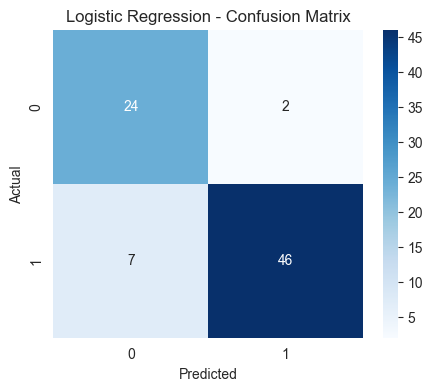

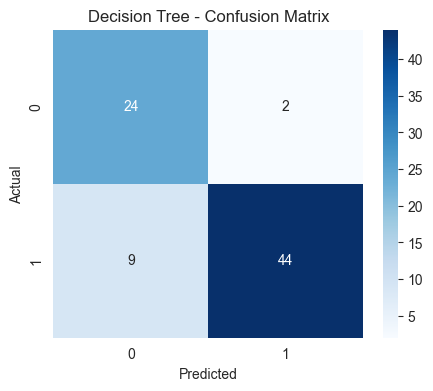

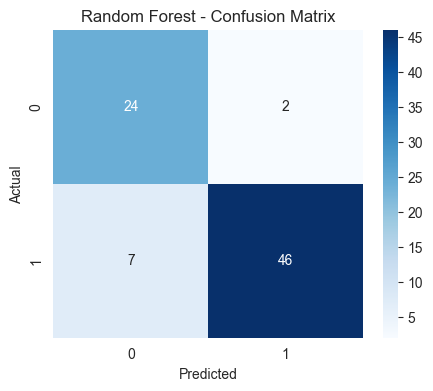

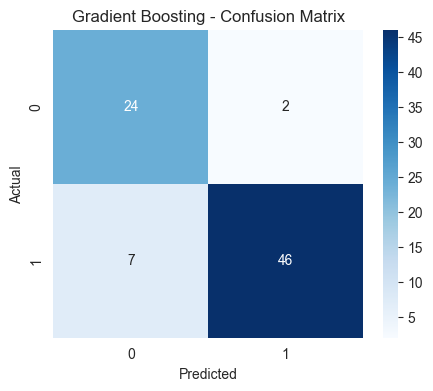

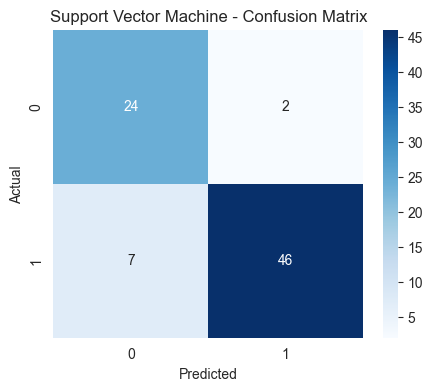

In [10]:
# Confusion Matrix Visualization
Path("../evaluation/confusion_matrices").mkdir(exist_ok=True)

for name, model in models.items():
    cm = confusion_matrix(y_test, model.predict(X_test))

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot = True, fmt = "d", cmap = "Blues")
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

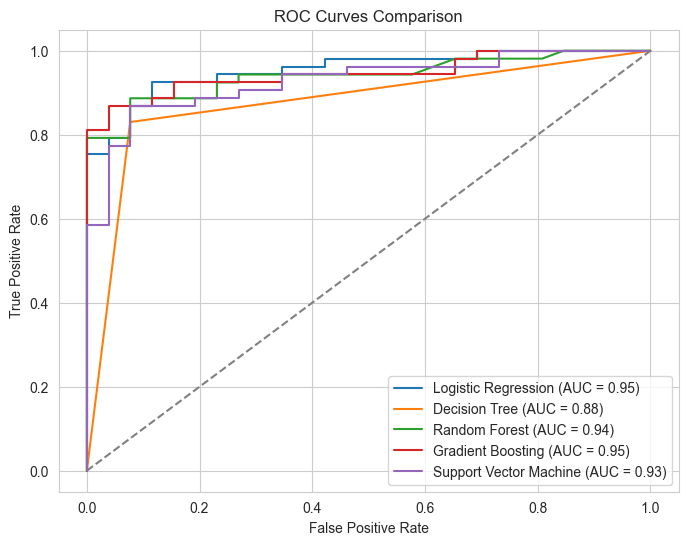

In [16]:
# ROC Curve Visualization

plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_prob = get_model_probalities(model, X_test)
    if y_prob is None:
        continue

    fpr, tpr, _ = roc_curve(y_test, y_prob)
    acu = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label = f"{name} (AUC = {acu:.2f})") 

plt.plot([0, 1], [0, 1], linestyle = "--", color = "gray")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves Comparison")
plt.legend()
plt.show()

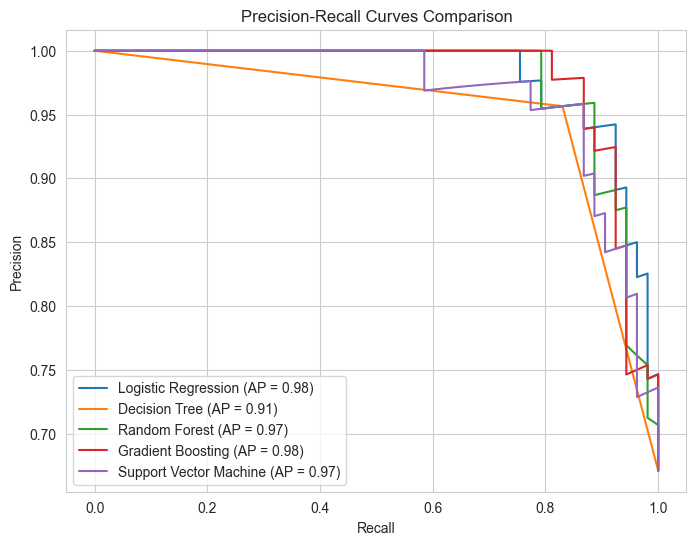

In [17]:
# Precision–Recall Curve

plt.figure(figsize=(8, 6))

for name,model in models.items():
    y_prob = get_model_probalities(model, X_test)
    if y_prob is None:
        continue

    precision, recall, _ = precision_recall_curve(y_test, y_prob)
    ap = average_precision_score(y_test, y_prob)
    plt.plot(recall, precision, label = f"{name} (AP = {ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curves Comparison")
plt.legend()
plt.show()

In [18]:
# Cross-Validation Stability

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)
for name, model in models.items():
    scores = cross_val_score(model,X_test,y_test,cv=cv, scoring= "f1")
    print(f"{name} - F1 Score CV: {scores.mean():.4f} ± {scores.std():.4f}")

Logistic Regression - F1 Score CV: 0.9444 ± 0.0526
Decision Tree - F1 Score CV: 0.9104 ± 0.0827
Random Forest - F1 Score CV: 0.9272 ± 0.0617
Gradient Boosting - F1 Score CV: 0.9342 ± 0.0481
Support Vector Machine - F1 Score CV: 0.9048 ± 0.0733


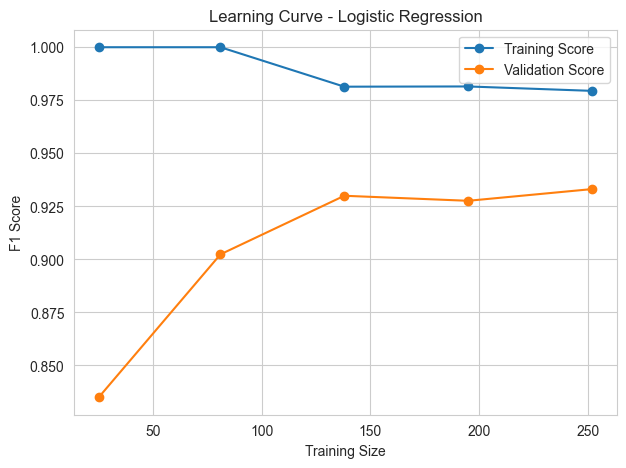

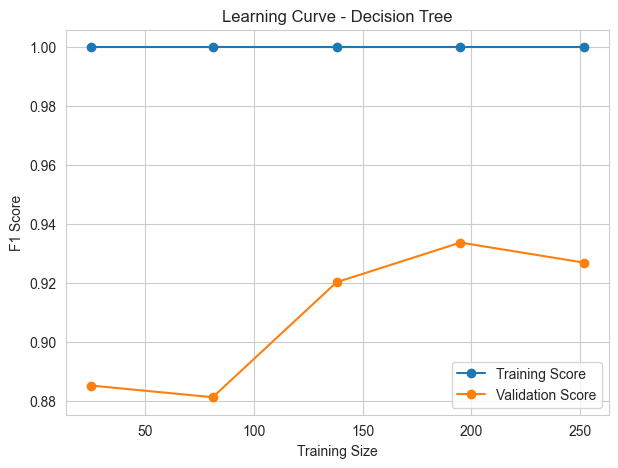

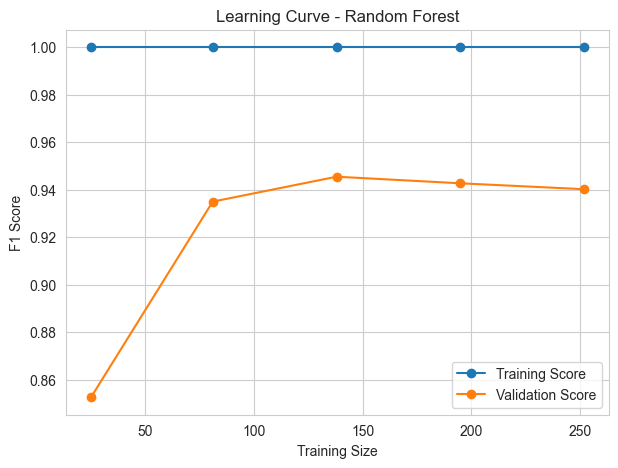

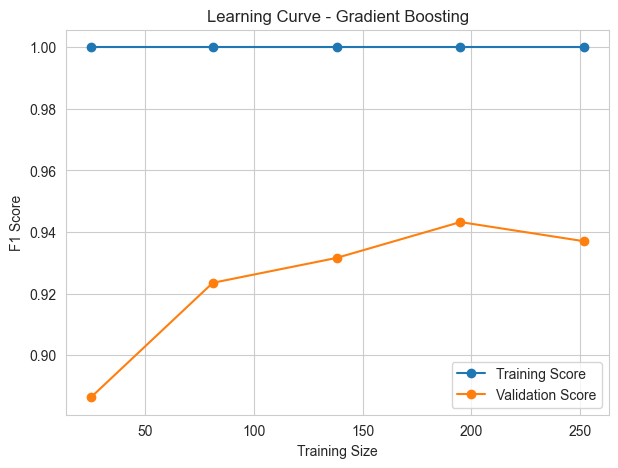

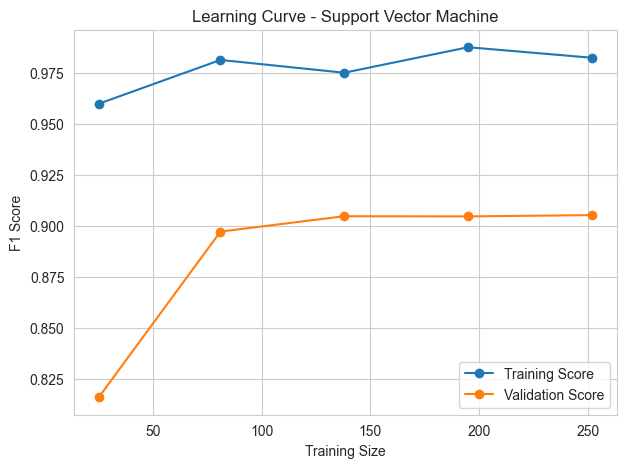

In [25]:
def plot_learning_curve(model, model_name, X, y):
    train_sizes, train_scores, test_scores = learning_curve(
        model,
        X,
        y,
        cv=5,
        scoring="f1",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5)
    )

    train_mean = train_scores.mean(axis=1)
    test_mean = test_scores.mean(axis=1)

    plt.figure(figsize=(7,5))
    plt.plot(train_sizes, train_mean, marker='o', label="Training Score")
    plt.plot(train_sizes, test_mean, marker='o', label="Validation Score")
    plt.title(f"Learning Curve - {model_name}")
    plt.xlabel("Training Size")
    plt.ylabel("F1 Score")
    plt.legend()
    plt.grid(True)
    plt.show()

X_train = pd.read_csv("../data/processed/X_train.csv")
y_train = pd.read_csv("../data/processed/y_train.csv").values.ravel()

for name, model in models.items():
    plot_learning_curve(model, name, X_train, y_train)




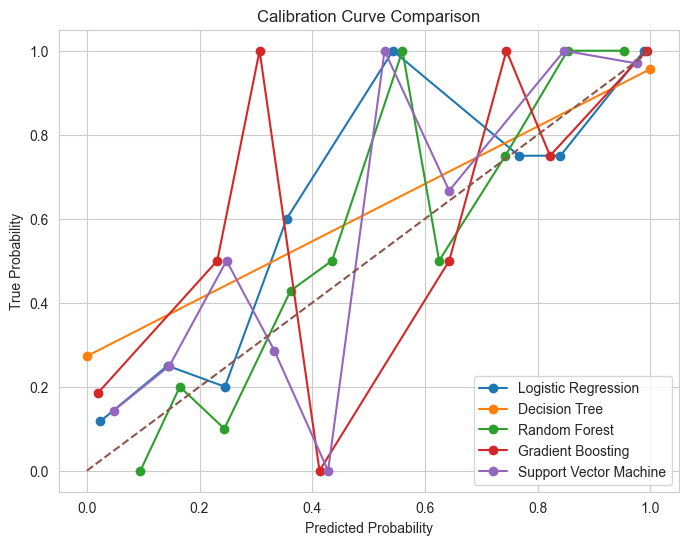

In [22]:
# Probability Calibration

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = get_model_probalities(model, X_test)
    if y_prob is None:
        continue

    prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)
    plt.plot(prob_pred, prob_true, marker="o", label=name)

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("Predicted Probability")
plt.ylabel("True Probability")
plt.title("Calibration Curve Comparison")
plt.legend()
plt.show()
